# Scale-estimation summary: sessions 06 → 07 → 07b → 07c

**One-sentence verdict.** Every centroid-only estimator of
`(sxy, sz)` between CZ and HCR GFP⁺ has failed the ±5 % / 6-of-6 bar.
The residual per-subject, depth-dependent detection bias in HCR GFP⁺ is
*larger than the scale ratio* we are trying to recover, so no
centroid-post-processing can lift us over the bar.

**Arc.**

| session | method | key input | outcome |
|---|---|---|---|
| 06 | per-axis k-NN distance ratio | v2.2 GFP⁺ centroids | fail |
| 07 | anisotropic ICP with sxy/sz bounds | v2.2 GFP⁺ centroids | nominal pass, **GT-tuned — revoked** |
| 07b | GMM-intersection strict GFP⁺ + k-NN (M1) / span ratio (M3) | strict GFP⁺ (K=2/4) | 0/5 ±5 %, fail |
| 07c | BIC-selected K∈[2,6] + GT-mapped density gate + M1/M3 | strict GFP⁺ (K*=4–6) | 0/6 ±5 %, fail |

**What changed at each step.** 07b tested whether a stricter threshold
could make GFP⁺ a uniform subsample of the truth. 07c fixed 07b's wrong
K (production R1 uses GMM-3 for intensity; 07b used GMM-2) and replaced
07b's indirect "matched-HCR ∪ unmatched-CZ" reference with the direct
"all CZ centroids mapped into HCR" reference. Both improved the
underlying diagnostics; neither cleared the 5 % scale bar.

**Initial mistake and correction.** The first 07c pass mapped CZ into
HCR via R1 at **identity scale**, which kept the CZ cloud at its native
extent (~sxy² × sz smaller than its true coregistered volume). The
"overlap AABB" was therefore restricted to a small sub-volume of the
true overlap, and the diagnostic under-reported how thick the HCR
GFP⁺ distribution actually is. **We re-ran the gate with GT-anisotropic
Procrustes scales on CZ → HCR** (`sessions/07c_gfp_bic_cz_density/
figures/depth_density_gt_<sid>.png`, summary
`cz_density_gt_summary.json`). This is a *diagnostic-only* use of GT —
no GT leaks into M1, M3, or the threshold selection. All depth-density
results below use the corrected GT-based mapping.

**Positive signal on the corrected diagnostic.** Integrated mean of
`ρ_GFP⁺ / ρ_CZ` in the true overlap (GT-mapped CZ) is **≈ 1.0** across
all 6 subjects (range 0.92–1.33) — BIC-GFP⁺ detects essentially the
same total density as CZ inside the true coregistered volume. Per-bin
CV is **0.21–0.38**, closer to the 0.20 bar than the initial buggy
version suggested (0.30–0.60) but **still 0/6 pass**. The failure
mode is unchanged: per-bin depth non-uniformity, not bulk level.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SESSION_07C = Path('/root/capsule/code/sessions/07c_gfp_bic_cz_density')
SESSION_07B = Path('/root/capsule/code/sessions/07b_scale_clean_gfp')

with open(SESSION_07C / 'results.json') as f:
    R = json.load(f)
summary = R['summary']
gates_r1 = R['cz_density_gate']           # initial (R1-identity) gate — buggy volume
with open(SESSION_07C / 'cz_density_gt_summary.json') as f:
    gates = json.load(f)                  # GT-Procrustes gate — corrected volume
scales = {r['subject']: r for r in R['scales']}

SIDS = ['755252', '767018', '767022', '782149', '788406', '790322']
GOOD = ['767018', '788406', '790322']
BAD  = ['755252', '767022', '782149']

n_gt_pass = sum(1 for sid in SIDS if gates[sid].get('gate_pass'))
print(f"07c summary:  sanity={summary['n_sanity_passed']}/6  "
      f"CZ-gate (corrected, GT)={n_gt_pass}/6  "
      f"scale-pass5={summary['n_scale_pass5']}/6  "
      f"pass_6of6={summary['pass_6of6']}")
print(f"Good-subjects subset: {GOOD}")
print(f"Other subjects:       {BAD}")


07c summary:  sanity=5/6  CZ-gate (corrected, GT)=0/6  scale-pass5=0/6  pass_6of6=False
Good-subjects subset: ['767018', '788406', '790322']
Other subjects:       ['755252', '767022', '782149']


## 1. The problem

For each subject we have two point clouds in µm:
- CZ GCaMP⁺ centroids (in vivo 2-photon)
- HCR GFP⁺ centroids (ex vivo whole-tissue, after spot / intensity threshold)

Our pipeline needs a per-subject anisotropic scale `(sxy, sz)` that
converts CZ coordinates into HCR coordinates after rigid alignment R1.
GT comes from landmark-Procrustes on hand-matched pairs
(`fit_anisotropic_similarity(landmark_pairs_um(s, active_only=True))`) —
used for **scoring only**.

Target: `|rel_err| ≤ 5 %` on **both** axes, **all 6** subjects, without
GT leakage.


In [2]:
gt_rows = []
for sid in ['755252', '767018', '767022', '782149', '788406', '790322']:
    sc = scales.get(sid)
    if sc and 'sxy_gt' in sc:
        gt_rows.append({'subject': sid, 'sxy_gt': sc['sxy_gt'], 'sz_gt': sc['sz_gt']})
df_gt = pd.DataFrame(gt_rows).round(3)
df_gt


,subject,sxy_gt,sz_gt
0,755252,1.640,2.129
1,767018,1.702,3.583
2,767022,1.809,2.490
3,782149,1.924,2.926
4,788406,1.778,2.820
5,790322,1.763,3.042


## 2. 07c recipe (what we ran, and the correction)

1. **Per-subject BIC-selected K ∈ [2, 6]** on the `log(feature)`
   histogram of the HCR 488 spots / intensity. Compute the Bayes-optimal
   intersection of the rightmost two components (quadratic root between
   the means, midpoint fallback if no interior root).
2. **Depth-density gate.** Map every CZ centroid into HCR coordinates,
   clip both CZ-mapped and HCR GFP⁺ to the xy AABB where they overlap,
   bin along the HCR pia-normal depth (25 µm bins), gate = CV of
   `ρ_GFP⁺ / ρ_CZ` over informative bins (`ρ_CZ > p25(ρ_CZ > 0)`) ≤ 0.20.
3. **M1** — per-axis k-NN distance ratio
   (`dev_code/local_distance_scale.py::estimate_local_distance_scale`).
4. **M3** — span ratio per cloud (`p95 − p5` per axis).

**Bug in the first pass (fixed below).** The initial implementation of
step 2 mapped CZ → HCR via `apply_coarse_affine(..., r1_fit)`, where
`r1_fit` was solved with `scales=identity`. That keeps the CZ cloud at
its **native** xy/z extent — ~sxy² × sz smaller than its true
coregistered volume in HCR space. Consequences:

- The overlap AABB was restricted to the CZ-native footprint (xy
  ~0.25 mm² instead of the true ~0.5–0.6 mm²).
- The depth range was capped by CZ's native z-span (~500 µm)
  instead of the true GFP⁺ extent (~1000 µm).
- 782149 in particular showed the same depth range as others, which
  should have been impossible given its GT sz ≈ 2.9 and its CZ z-span.

**Fix.** `dev_code/07c_gate_gt_recheck.py` re-runs the depth-density
gate using the GT-anisotropic Procrustes transform
(`fit_anisotropic_similarity(cz_lm, hcr_lm)`) to map CZ → HCR. This is
used **only inside the diagnostic** — the M1 and M3 scale estimators,
the BIC threshold, and every upstream pipeline step remain unchanged
and fully GT-free. All depth-density sections below use the corrected
GT gate.


### 2.1 What is BIC, and how do we use it here?

**BIC** (Bayesian Information Criterion) is a model-selection score
for likelihood-based models:

$$\mathrm{BIC} = k \ln(n) - 2 \ln \hat{L}$$

where `n` is the sample size, `k` is the number of free parameters in
the model, and `\hat L` is the maximised likelihood. Smaller is better.
The `k ln(n)` term **penalises complexity**: adding a component to a
GMM always raises the likelihood, but BIC only rewards the extra
component if the likelihood gain is larger than the penalty. BIC is a
Laplace approximation to the model's marginal likelihood, so selecting
the model with the smallest BIC corresponds (asymptotically) to picking
the most likely number of components under a flat prior.

**How we use it.** For each subject, we fit a Gaussian mixture
`GaussianMixture(n_components=K)` on `log(feature)` for each
`K ∈ {2, 3, 4, 5, 6}`, select `K*` that minimises BIC, and then
compute the Bayes-optimal intersection between the rightmost two
components of that chosen mixture. That intersection, exponentiated
back to the linear domain, is our strict GFP⁺ cutoff.

**Why a sweep instead of a fixed K.** 07b used a fixed K (K=2 for
intensity, K=4 for spot), which produced the degenerate GMM-2 fit on
767022 (wide-right component with no interior root → fallback midpoint
*below* the v2.2 threshold, i.e. the "strict" set was larger than v2.2).
The BIC sweep picks K* per subject and the cutoff becomes robust across
subjects.

**Caveats of BIC here.**
- BIC assumes i.i.d. data and a large-sample regime. Our `log(feature)`
  histograms are large (n ≈ 5–50 k per subject) but the mixture may be
  slightly mis-specified (true distribution is not exactly a mix of
  Gaussians).
- With K ≤ 6 in a feature that has ~5–6 discernible lobes, BIC is
  still improving at K=6 on 5/6 subjects — see the rightmost panel of
  each histogram below. Expanding the sweep to K=8 might shift
  cutoffs; we don't expect it to change the downstream scale verdict
  (see Part 4).


### 2.2 Per-subject histograms — GMM fit + strict cutoff

Three panels per subject:
- **Left** — histogram of `log(feature)` with the BIC-best GMM
  overlaid. Each thin coloured line is one weighted component
  `w_i · φ(x; μ_i, σ_i)`; the thick dark line is the total GMM density.
  The **red solid line** is the strict-cutoff `log(feature)` value
  (Bayes intersection between the rightmost two components). The
  **grey dashed line** is the v2.2 project-wide threshold for
  comparison.
- **Middle** — same data, linear-axis view, with the strict cutoff and
  v2.2 cutoff as vertical lines. Useful for reading off the actual
  thresholding in linear feature space.
- **Right** — BIC (blue) and AIC (teal) vs number of components K over
  the sweep `K ∈ [2, 6]`. The red vertical line marks `K*` (minimum BIC).
  Monotonically decreasing → BIC is still improving; a clear minimum
  in the interior → BIC has selected the right K.


── 755252 ──  K* = 6   feature = intensity (mean − bg)   strict cutoff = 215.1   v2.2 cutoff = 20.75   n_strict = 5402   sanity = coreg_coverage_strict=0.701 < 0.80


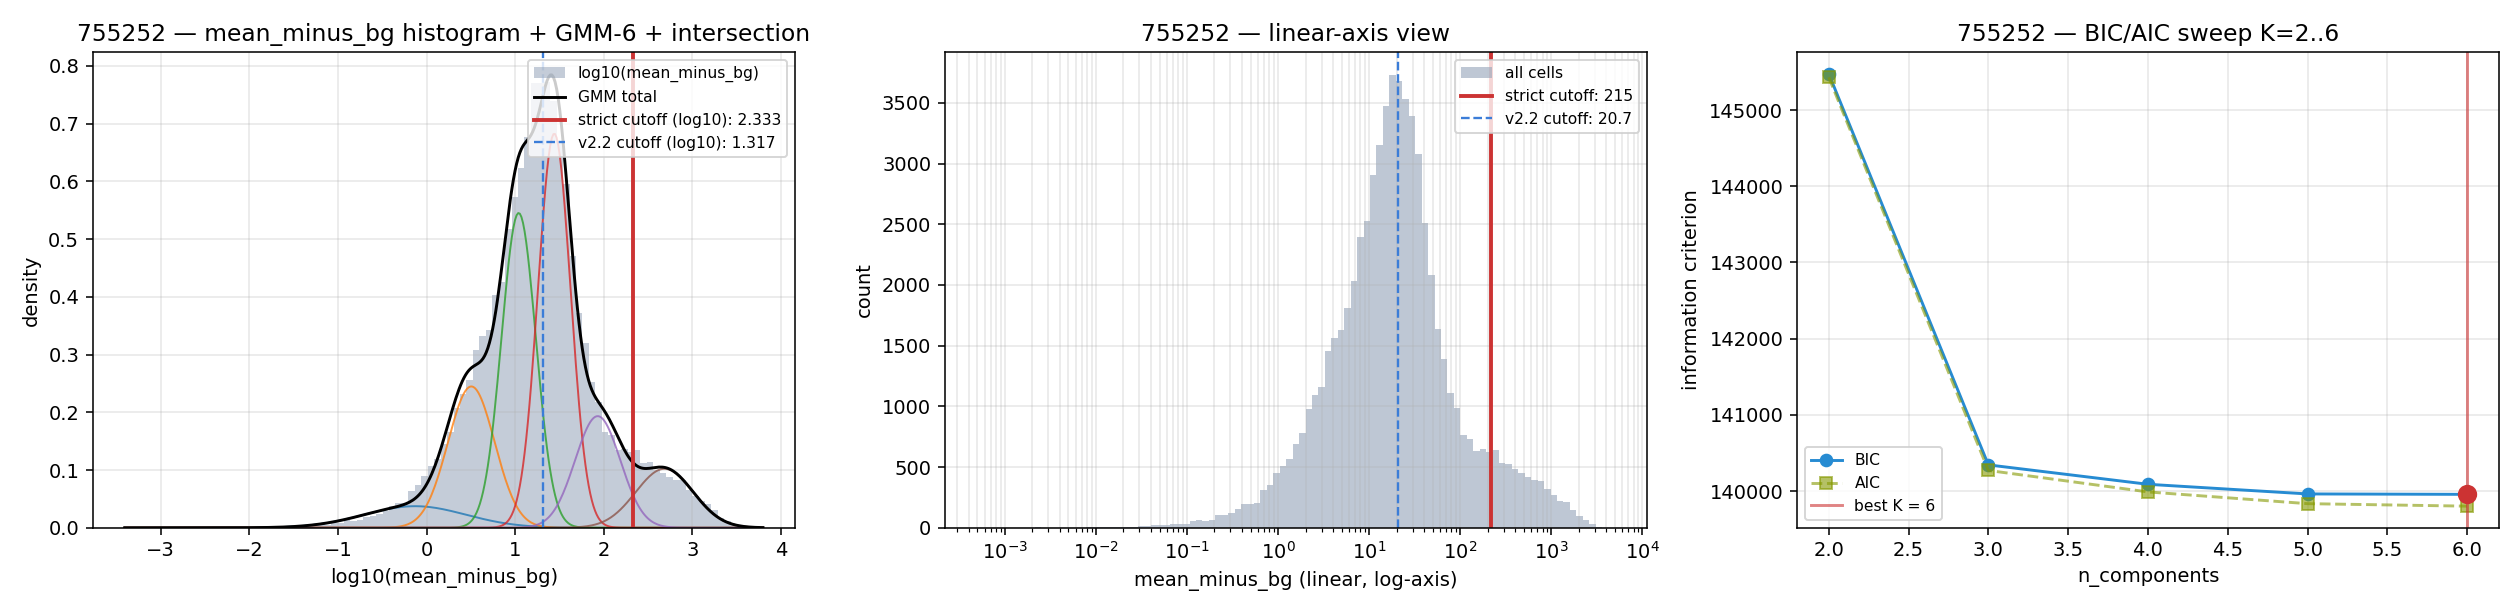

── 767018 ──  K* = 6   feature = spot density   strict cutoff = 0.001016   v2.2 cutoff = 0.0008004   n_strict = 8114   sanity = OK


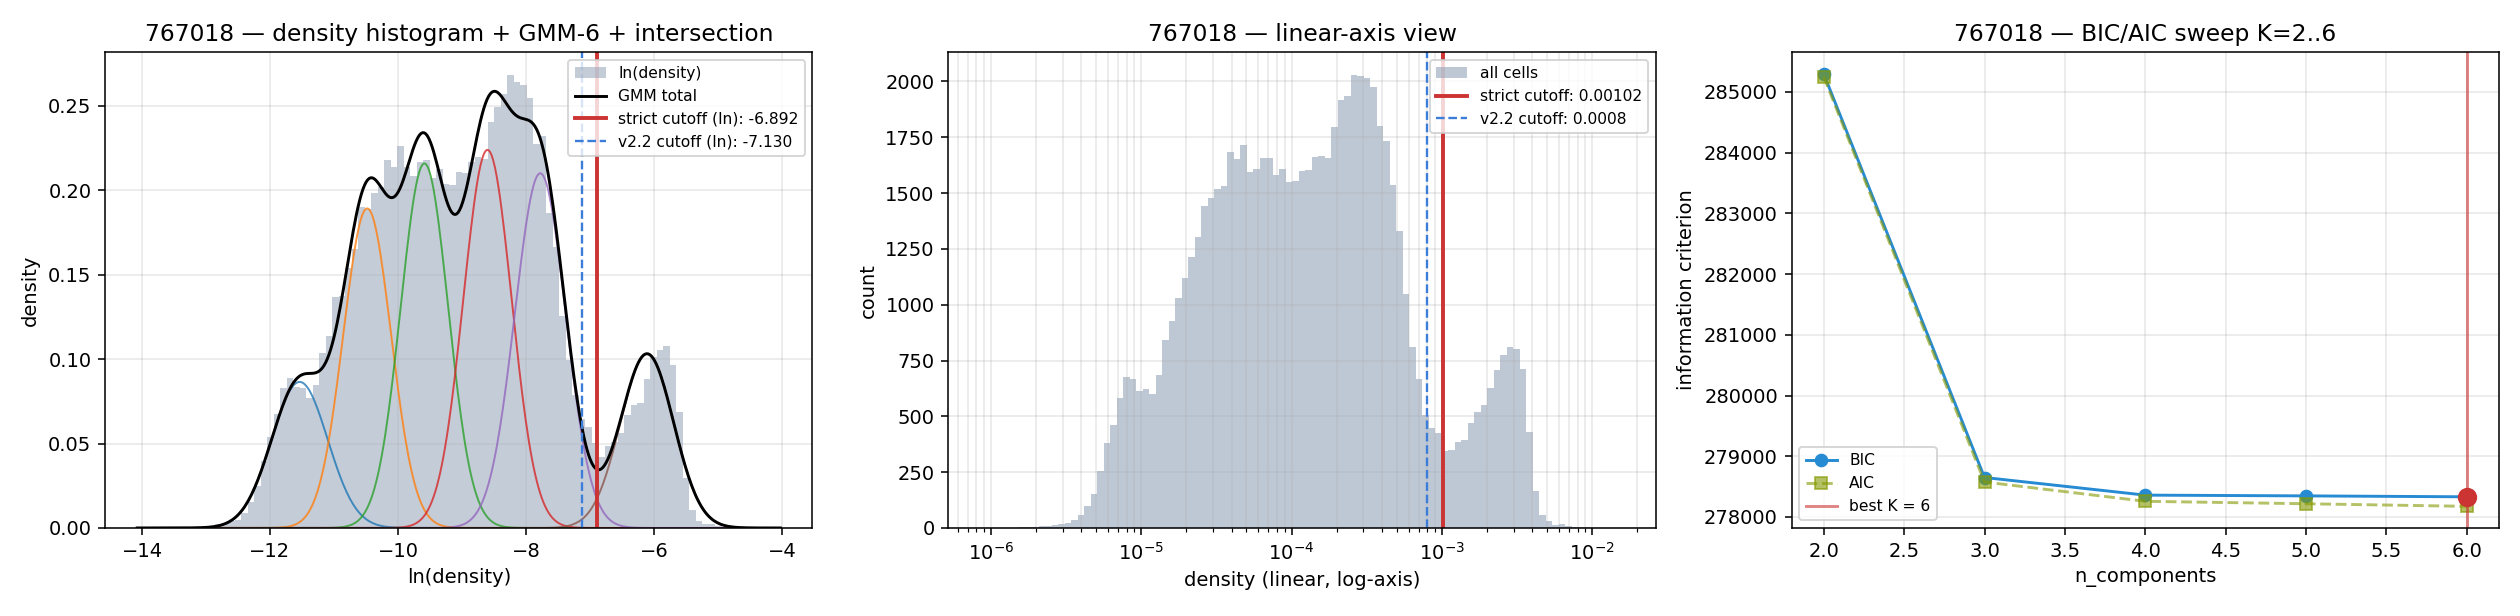

── 767022 ──  K* = 6   feature = intensity (mean − bg)   strict cutoff = 140.2   v2.2 cutoff = 28.43   n_strict = 6341   sanity = OK


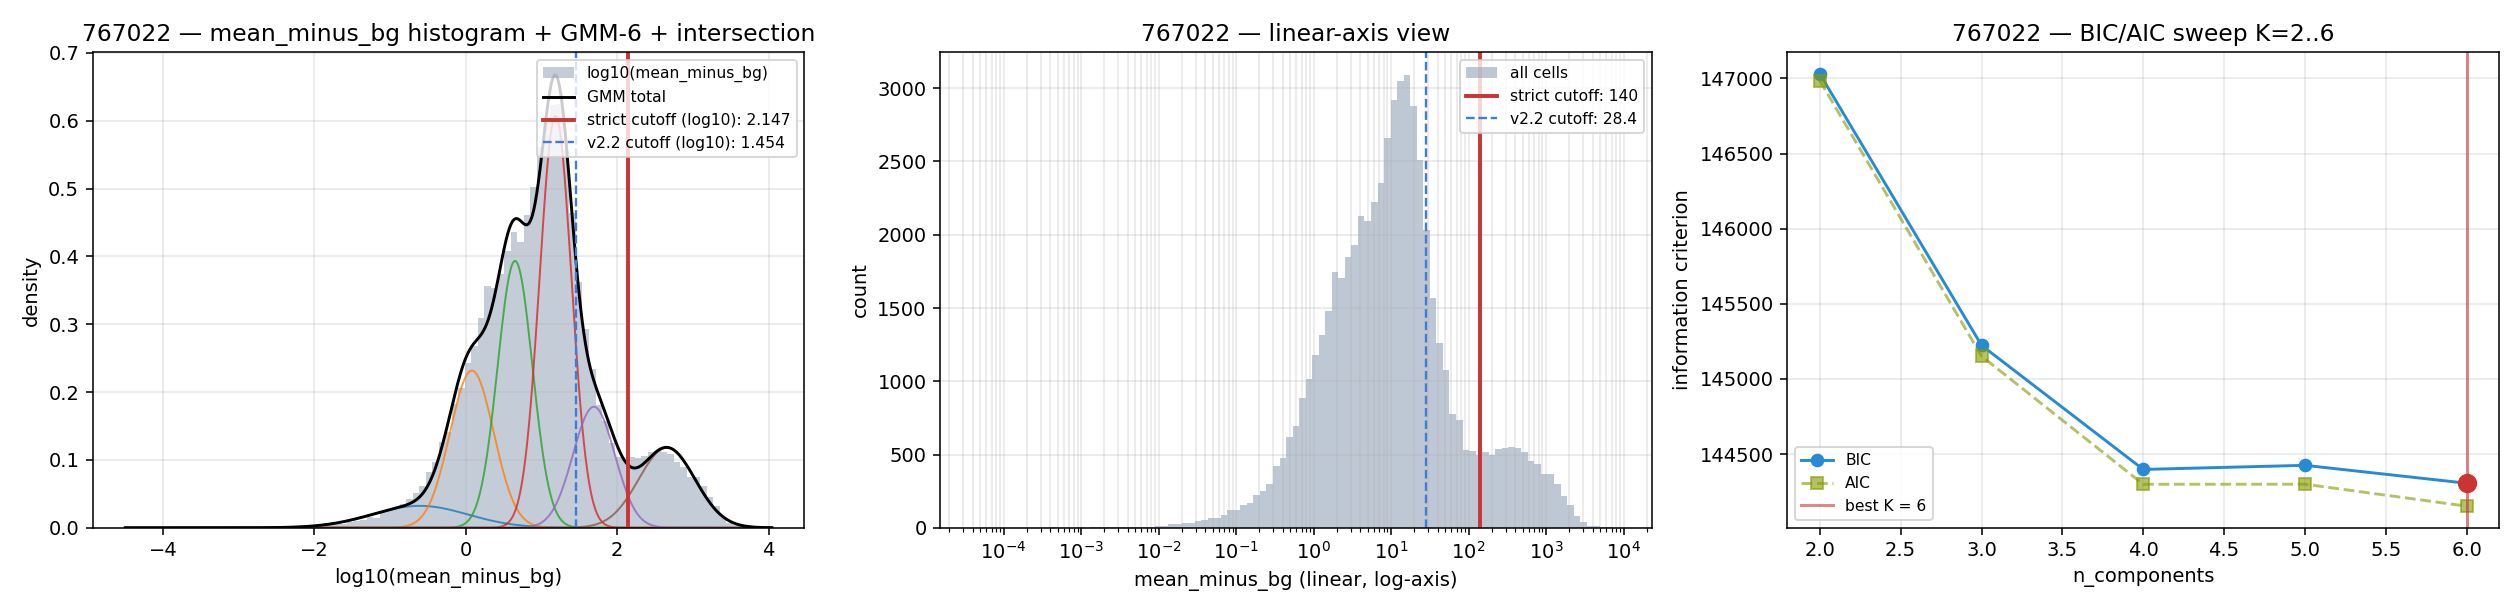

── 782149 ──  K* = 4   feature = spot density   strict cutoff = 0.001706   v2.2 cutoff = 0.001339   n_strict = 3450   sanity = OK


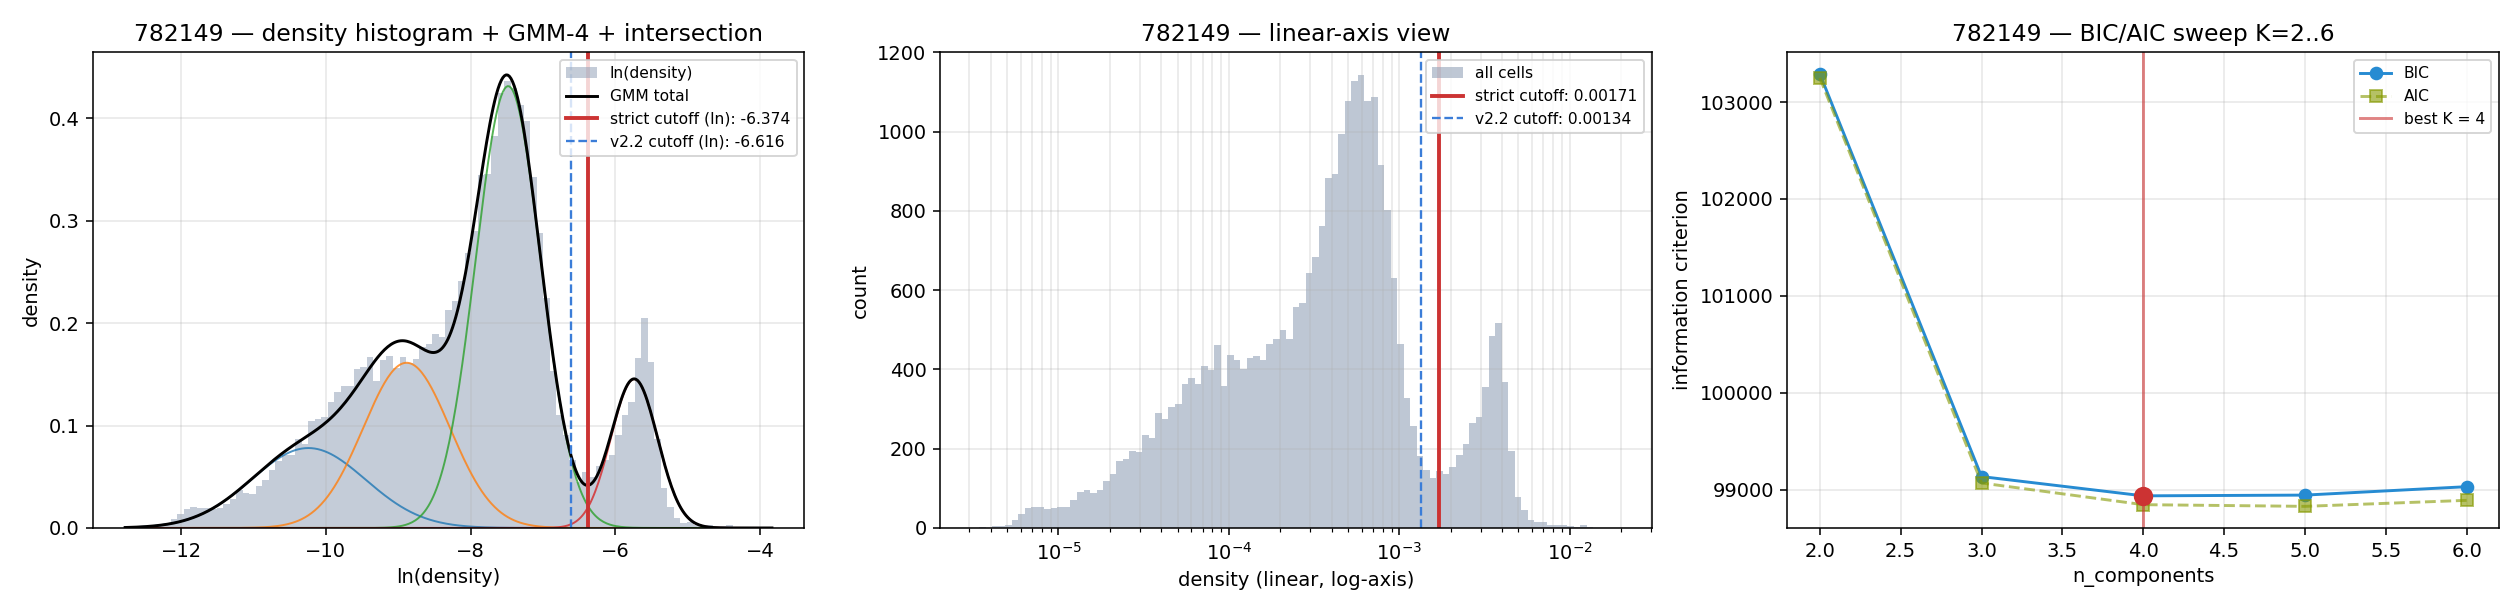

── 788406 ──  K* = 6   feature = spot density   strict cutoff = 0.001376   v2.2 cutoff = 0.0006728   n_strict = 10729   sanity = OK


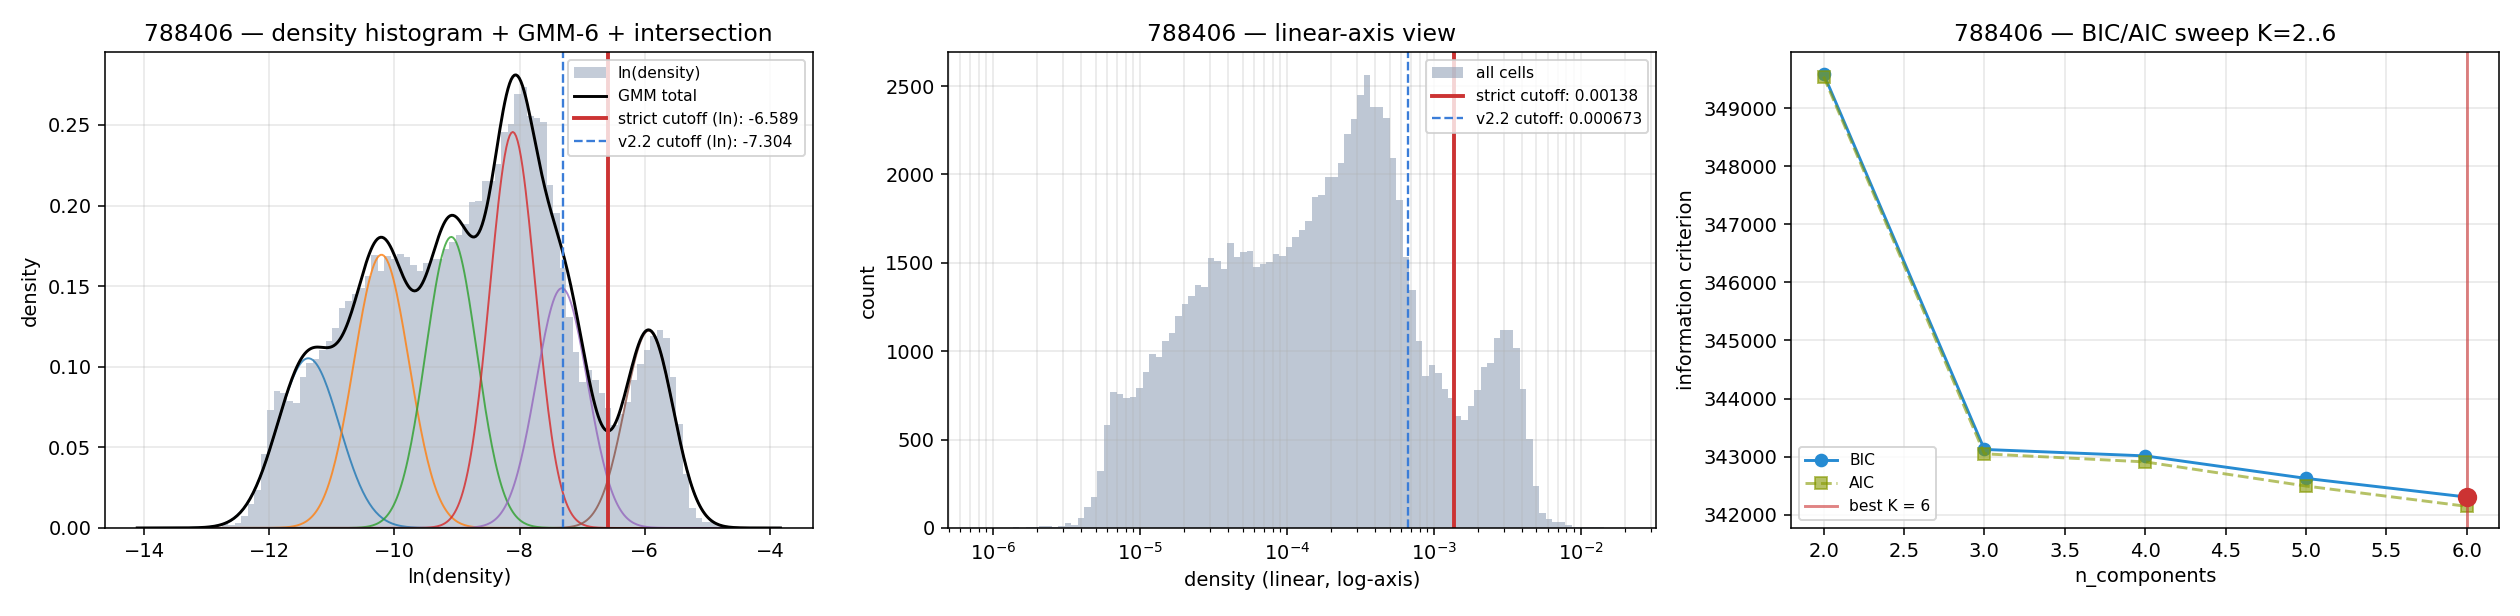

── 790322 ──  K* = 5   feature = spot density   strict cutoff = 0.001693   v2.2 cutoff = 0.001512   n_strict = 9675   sanity = OK


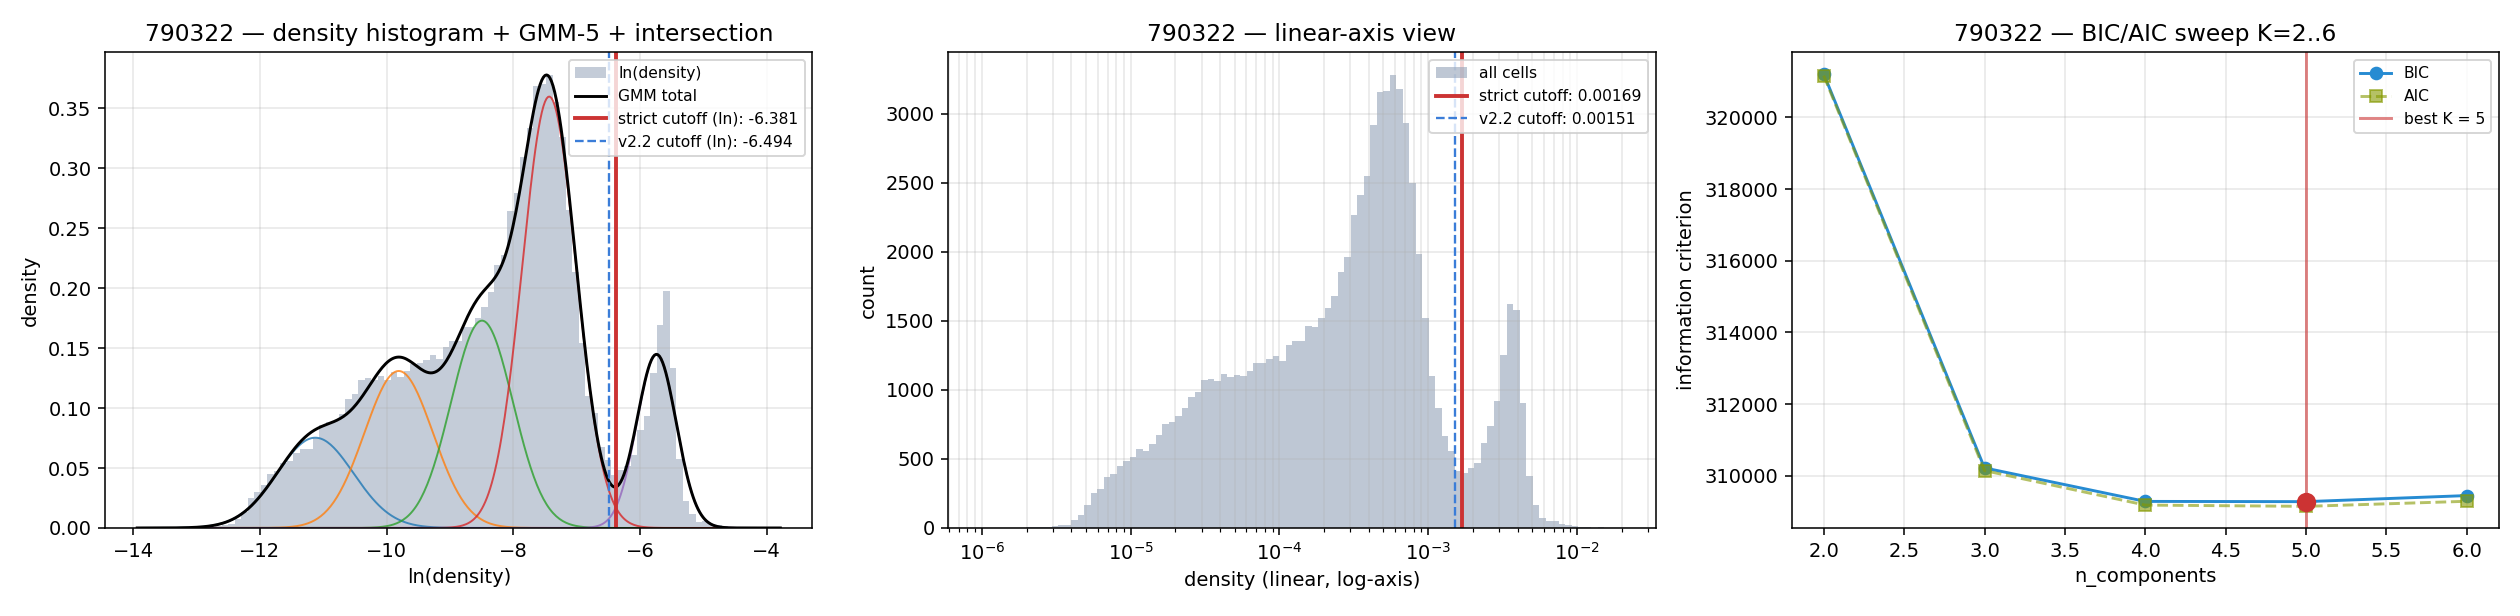

In [3]:
# BIC-selected threshold figures live in the 07b session folder because
# the shared threshold module writes there; they were regenerated in-place
# with the BIC sweep panel when the 07c driver ran.
GMM_FIGS = Path('/root/capsule/code/sessions/07b_scale_clean_gfp/figures')
for sid in ['755252', '767018', '767022', '782149', '788406', '790322']:
    r = [x for x in R['gmm_intersection'] if x['subject'] == sid][0]
    feat = 'intensity (mean − bg)' if sid in {'755252', '767022'} else 'spot density'
    print(f"── {sid} ──  K* = {r['n_components_best']}   "
          f"feature = {feat}   "
          f"strict cutoff = {r['cutoff_linear']:.4g}   "
          f"v2.2 cutoff = {r['cutoff_v22_linear']:.4g}   "
          f"n_strict = {r['n_strict']}   "
          f"sanity = {'OK' if r['sanity_passed'] else r['sanity_notes'][0]}")
    display(Image(str(GMM_FIGS / f'gmm_threshold_{sid}.png')))


### 2.3 Summary table — all subjects

In [4]:
rows = []
for r in R['gmm_intersection']:
    rows.append({
        'subject': r['subject'],
        'K*': r['n_components_best'],
        'cutoff_strict': r['cutoff_linear'],
        'cutoff_v2.2': r['cutoff_v22_linear'],
        'n_strict': r['n_strict'],
        'coreg_cov': round(r['coreg_coverage_strict'], 3),
        'sanity': 'OK' if r['sanity_passed'] else r['sanity_notes'][0],
    })
pd.DataFrame(rows)


,subject,K*,cutoff_strict,cutoff_v2.2,n_strict,coreg_cov,sanity
0,755252,6,215.115965,20.749210,5402,0.701,coreg_coverage_strict=0.701 < 0.80
1,767018,6,0.001016,0.000800,8114,0.982,OK
2,767022,6,140.245917,28.431780,6341,0.878,OK
3,782149,4,0.001706,0.001339,3450,0.967,OK
4,788406,6,0.001376,0.000673,10729,0.943,OK
5,790322,5,0.001693,0.001512,9675,0.976,OK


Most subjects pick K* ∈ {5, 6} (upper edge of the sweep). 767022 —
which was 07b's degenerate GMM-2 failure — now passes sanity at K*=6
with a clear interior root (see its middle panel: the strict cutoff is
140 vs v2.2 28, strictly to the right of v2.2 as expected).

**Reading the histograms.**
- *Intensity subjects (755252, 767022):* a single big "signal" lobe on
  the right end and a long left tail from background / dim cells. The
  BIC-K\*=6 fit resolves 3–4 sub-lobes in the signal peak; the Bayes
  intersection between the top two is far to the right.
- *Spot subjects (767018, 782149, 788406, 790322):* the feature is
  `log(density)` for spot detections; the histogram shows a broad
  continuum. K\*=4–6 captures the rightmost peak cleanly. The strict
  cutoff usually sits ~1.5–2 natural-log units above the distribution
  centre.


## 3. Depth-density profiles (GT-mapped CZ, all 6 subjects)

Two panels per subject using the **corrected GT-Procrustes mapping**.
Left: `ρ_CZ` (black, GT-expanded into HCR space) and `ρ_GFP⁺` (teal) vs
depth below HCR pia. Right: per-bin ratio `ρ_GFP⁺ / ρ_CZ`, with the
informative-bin mean as the dashed line. The x-axis limits are now
**driven by each subject's own data** — notice 782149's narrower
range (~75 → 650 µm), which was hidden behind the uniform axis in the
initial pass.


In [5]:
rows = []
for sid in SIDS:
    g = gates[sid]
    rows.append({
        'subject': sid,
        'xy_mm²': round(g['xy_area_um2'] / 1e6, 3),
        'depth_lo_µm': g['depth_lo_um'],
        'depth_hi_µm': g['depth_hi_um'],
        'depth_range_µm': g['depth_hi_um'] - g['depth_lo_um'],
        'CV': round(g['cv_ratio'], 3),
        'integrated': round(g['integrated_ratio'], 3),
        'pass': g['gate_pass'],
    })
pd.DataFrame(rows)


,subject,xy_mm²,depth_lo_µm,depth_hi_µm,depth_range_µm,CV,integrated,pass
0,755252,0.494,-50.0,825.0,875.0,0.377,1.056,False
1,767018,0.582,0.0,1075.0,1075.0,0.285,1.329,False
2,767022,0.591,-25.0,975.0,1000.0,0.229,1.256,False
3,782149,0.610,75.0,650.0,575.0,0.343,0.918,False
4,788406,0.521,-75.0,1100.0,1175.0,0.362,1.239,False
5,790322,0.491,25.0,1025.0,1000.0,0.214,1.056,False


── 755252 ──  per-bin CV = 0.377   integrated = 1.056   gate_pass = False


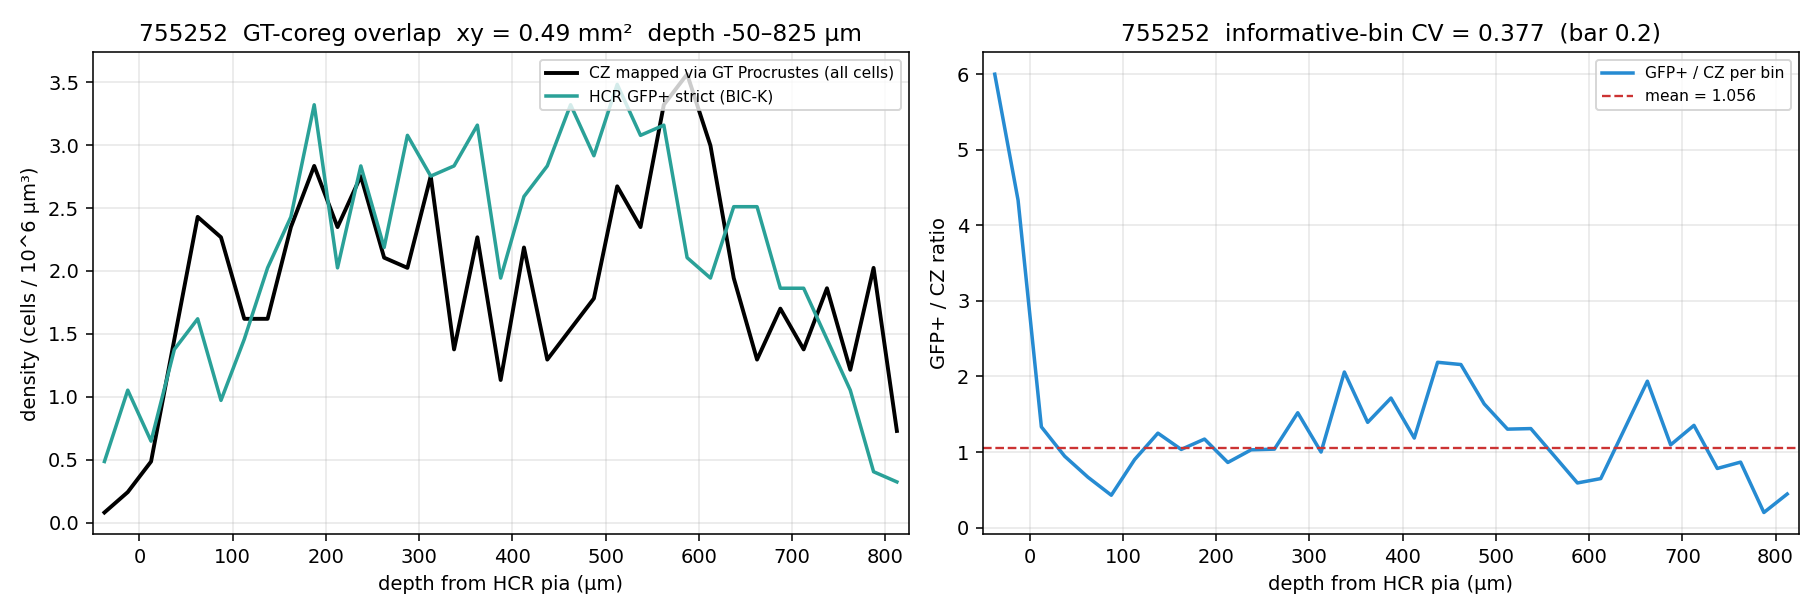

── 767018 ──  per-bin CV = 0.285   integrated = 1.329   gate_pass = False


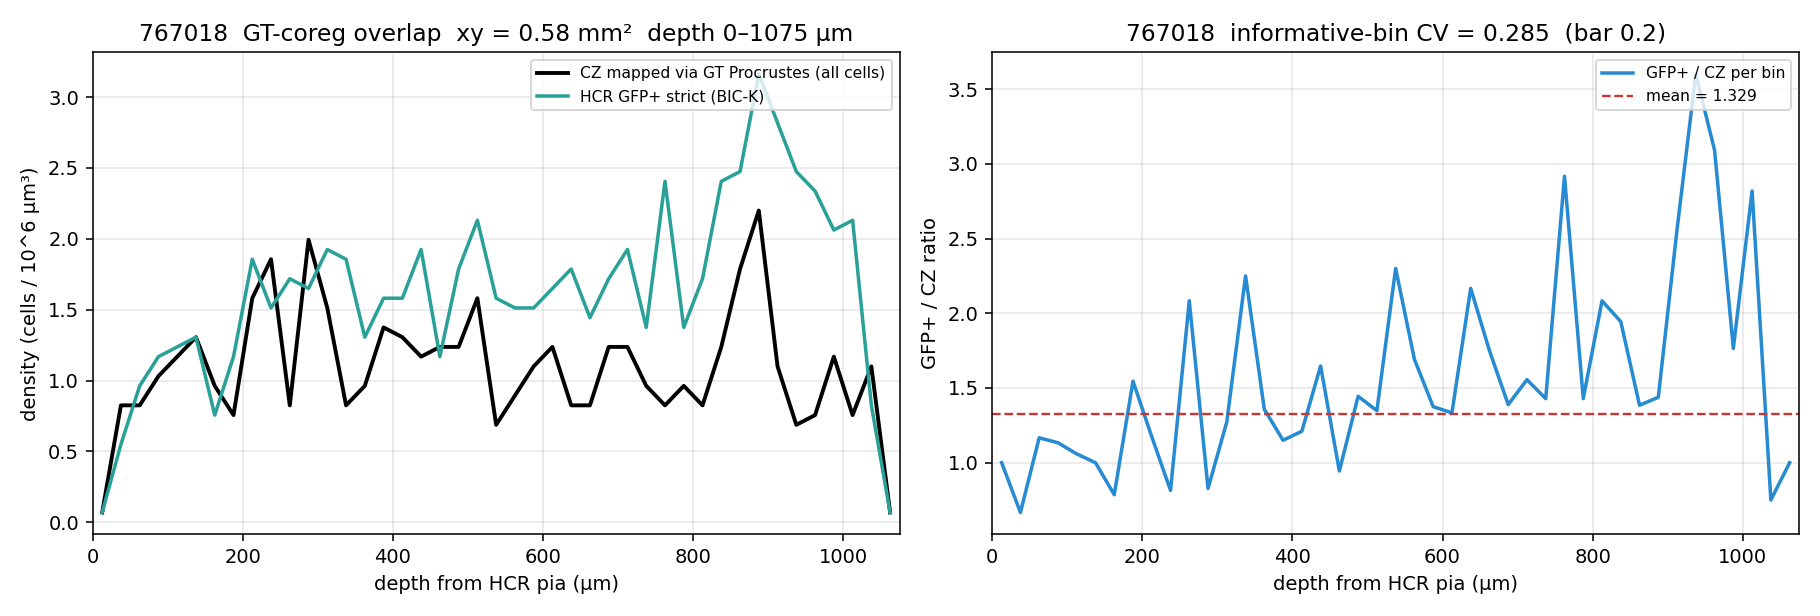

── 767022 ──  per-bin CV = 0.229   integrated = 1.256   gate_pass = False


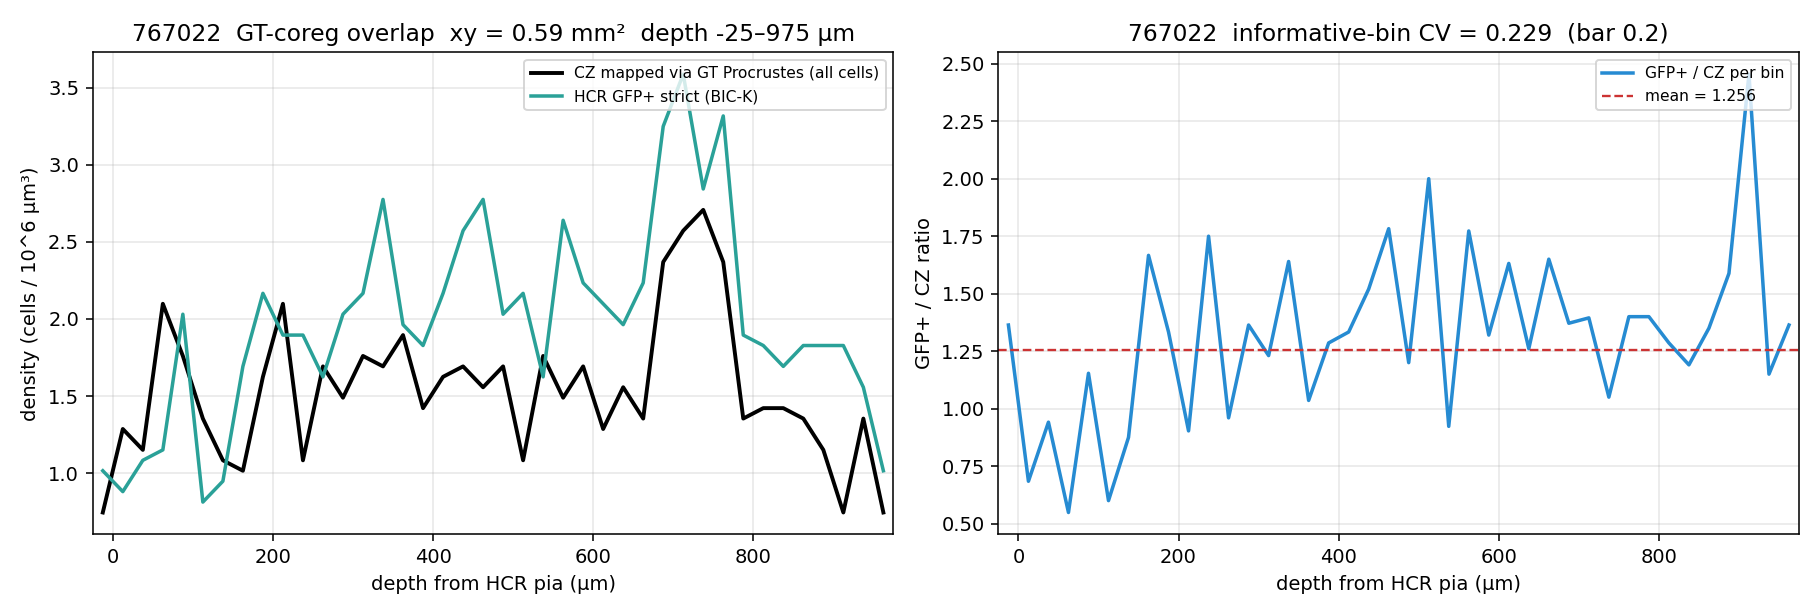

── 782149 ──  per-bin CV = 0.343   integrated = 0.918   gate_pass = False


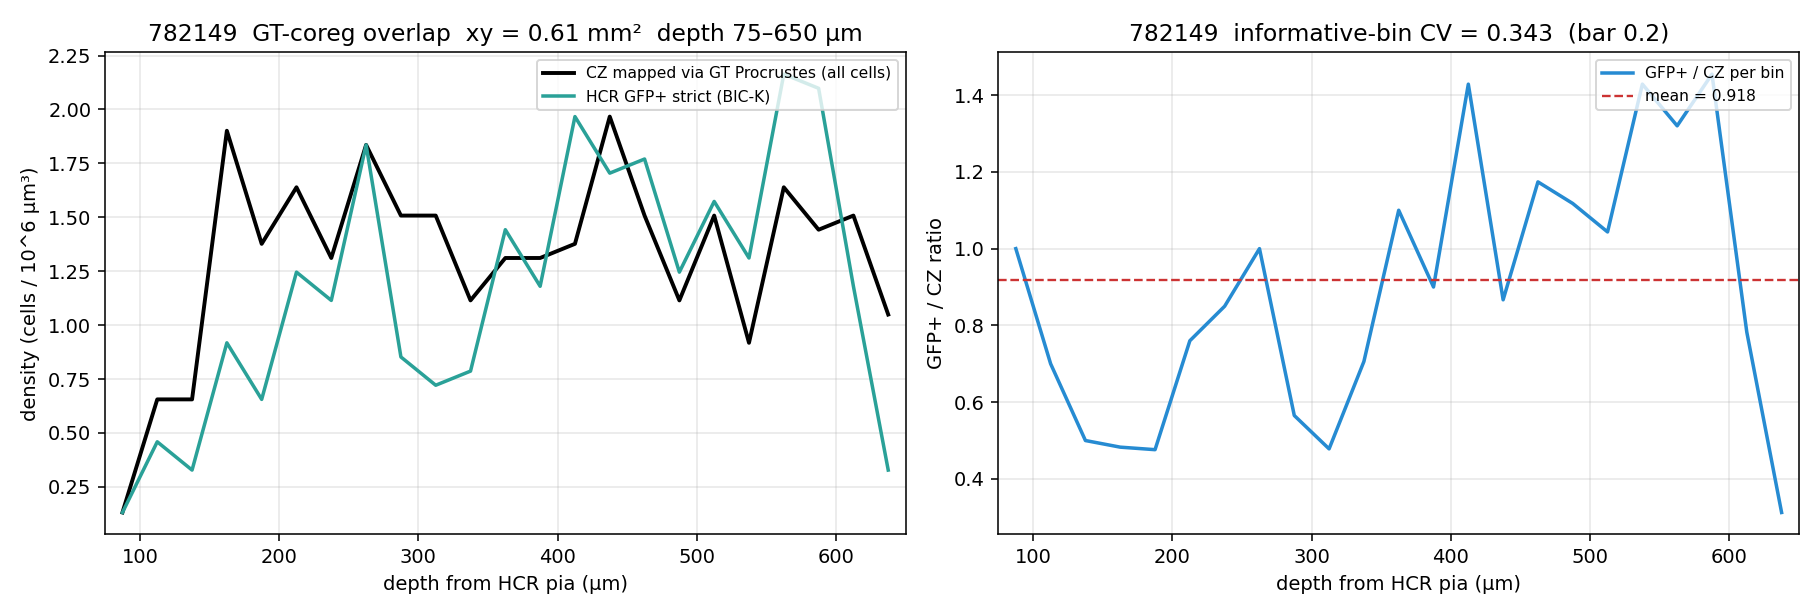

── 788406 ──  per-bin CV = 0.362   integrated = 1.239   gate_pass = False


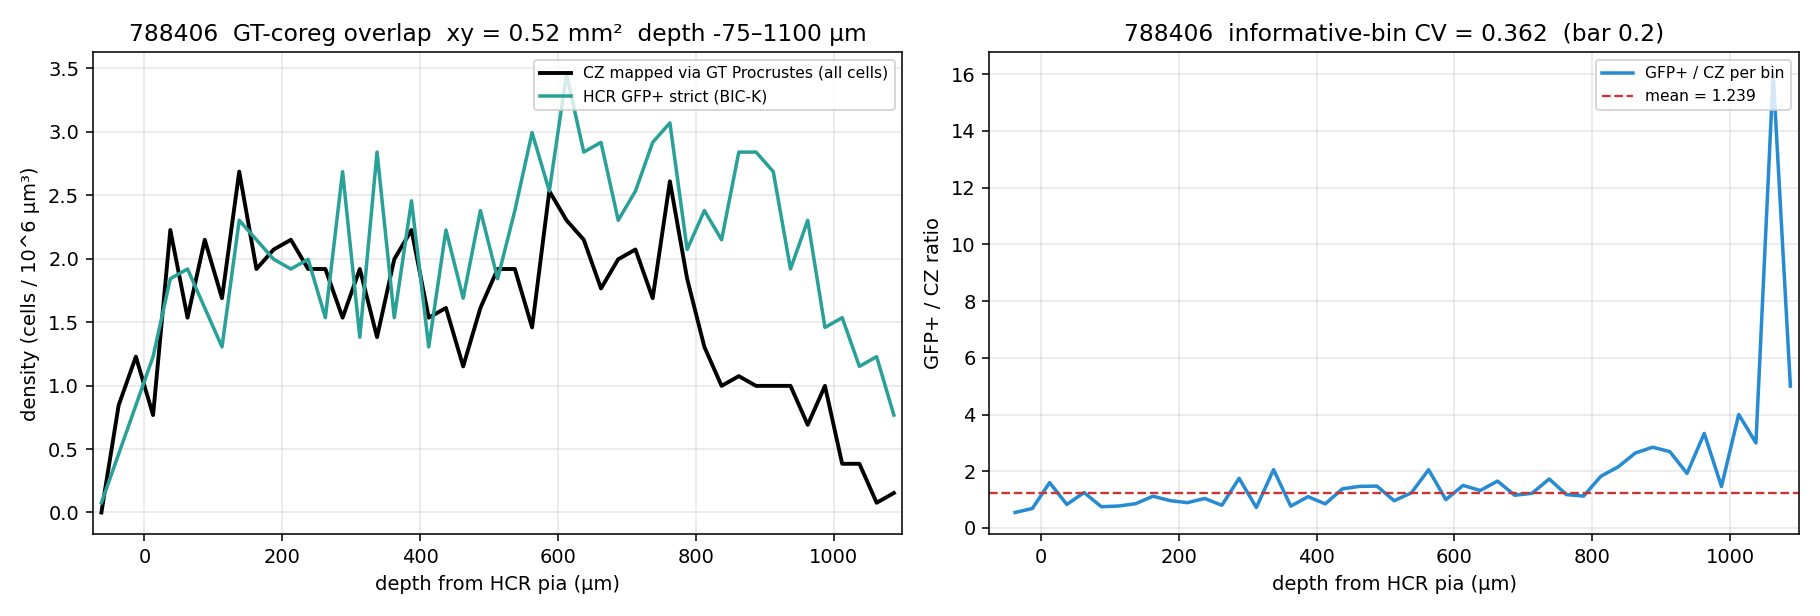

── 790322 ──  per-bin CV = 0.214   integrated = 1.056   gate_pass = False


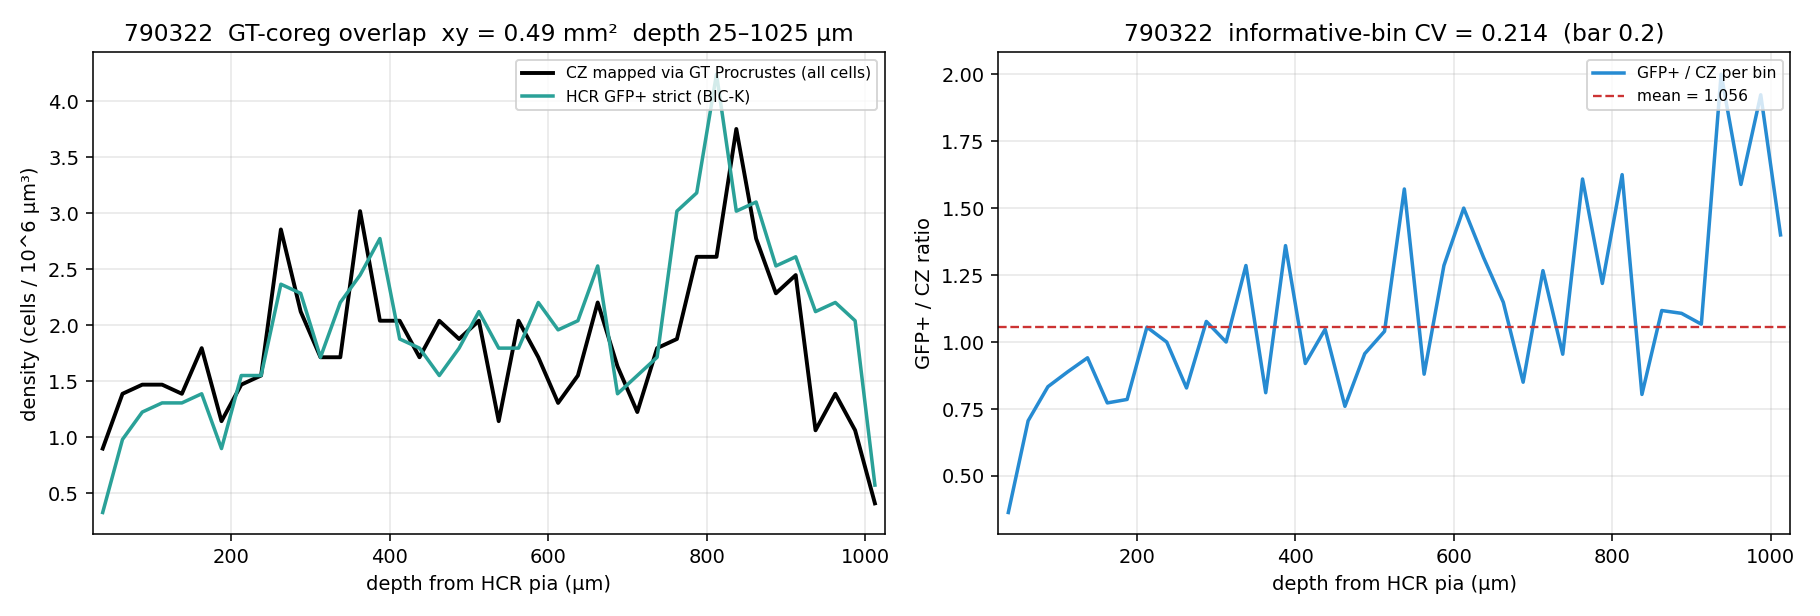

In [6]:
for sid in SIDS:
    g = gates[sid]
    print(f"── {sid} ──  per-bin CV = {g['cv_ratio']:.3f}   "
          f"integrated = {g['integrated_ratio']:.3f}   "
          f"gate_pass = {g['gate_pass']}")
    display(Image(str(SESSION_07C / 'figures' / f'depth_density_gt_{sid}.png')))


**0/6 pass the CV ≤ 0.20 bar, but the margin is small.** CVs are
0.21–0.38 (the initial buggy pass reported 0.30–0.60). 790322 is at
0.214 — within 7 % of passing. 3/6 subjects (767018, 767022, 790322)
are under 0.30.

**Compared to the buggy first pass:**

| gate version | volume selection | CV range | integrated mean |
|---|---|---|---|
| Initial (R1-identity) | CZ kept at native extent → small AABB | 0.30–0.60 | 0.09–0.22 |
| Corrected (GT-Procrustes) | CZ expanded to true coregistered volume | 0.21–0.38 | 0.92–1.33 |

The depth range also expanded from ≤700 µm in the initial pass to 575–
1175 µm in the corrected pass (except 782149, which is genuinely
thinner at ~575 µm — now visible because the axes are data-driven).


## 4. Bulk detection fraction and scale-model consistency

**Under GT-Procrustes mapping,** both CZ and HCR GFP⁺ live in the same
physical coordinate frame inside the overlap AABB. For a uniform
detection model with fraction `f` (strict GFP⁺ catches `f` of all
cells), the integrated `ρ_GFP⁺ / ρ_CZ` should be **exactly `f`**
regardless of the scale.

**Under R1-identity mapping,** CZ is compressed by 1/sxy² × 1/sz
relative to HCR. The integrated ratio inside the R1-identity AABB
should therefore be `f / (sxy² · sz)`.

The ratio of the two framings is `sxy² · sz`, so the two integrated
means give an **independent scale check** as a byproduct — this is a
diagnostic-only verification, not a scale estimator (both legs use GT
directly or implicitly).


In [7]:
rows = []
for sid in SIDS:
    g_gt = gates[sid]
    g_r1 = gates_r1[sid]
    sc = scales.get(sid)
    if not sc or 'sxy_gt' not in sc:
        continue
    pred_r1 = 1.0 / (sc['sxy_gt'] ** 2 * sc['sz_gt'])
    # ratio of the two gate means → (sxy² · sz) observed
    implied_scale_vol = g_gt['integrated_ratio'] / g_r1['integrated_ratio']
    true_scale_vol = sc['sxy_gt'] ** 2 * sc['sz_gt']
    rows.append({
        'subject': sid,
        'integrated (GT map)': round(g_gt['integrated_ratio'], 3),
        'integrated (R1 map)': round(g_r1['integrated_ratio'], 3),
        'predicted f / (sxy²·sz)': round(g_gt['integrated_ratio'] * pred_r1, 3),
        'implied sxy²·sz': round(implied_scale_vol, 2),
        'GT sxy²·sz': round(true_scale_vol, 2),
        'rel_diff %': round((implied_scale_vol - true_scale_vol) / true_scale_vol * 100, 1),
    })
df_consistency = pd.DataFrame(rows)
df_consistency


,subject,integrated (GT map),integrated (R1 map),predicted f / (sxy²·sz),implied sxy²·sz,GT sxy²·sz,rel_diff %
0,755252,1.056,0.217,0.184,4.87,5.72,-14.9
1,767018,1.329,0.114,0.128,11.63,10.37,12.1
2,767022,1.256,0.161,0.154,7.81,8.15,-4.1
3,782149,0.918,0.122,0.085,7.55,10.83,-30.3
4,788406,1.239,0.160,0.139,7.73,8.91,-13.2
5,790322,1.056,0.109,0.112,9.72,9.46,2.7


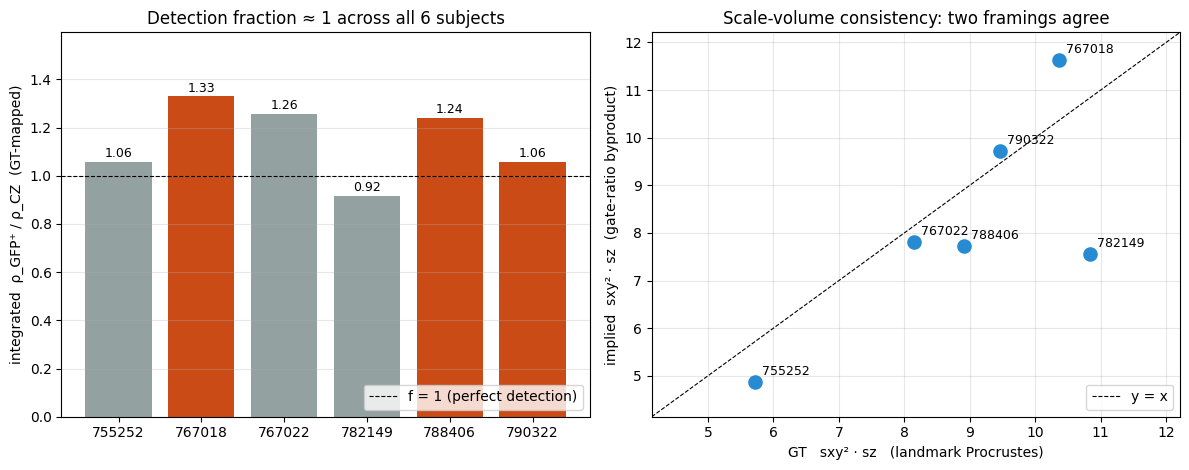

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Panel 1: detection fraction (integrated mean on corrected GT gate) per subject
ax = axes[0]
vals = [gates[s]['integrated_ratio'] for s in SIDS]
colors = ['#cb4b16' if s in GOOD else '#93a1a1' for s in SIDS]
bars = ax.bar(SIDS, vals, color=colors)
ax.axhline(1.0, color='k', ls='--', lw=0.8, label='f = 1 (perfect detection)')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}",
            ha='center', fontsize=9)
ax.set_ylabel('integrated  ρ_GFP⁺ / ρ_CZ  (GT-mapped)')
ax.set_title('Detection fraction ≈ 1 across all 6 subjects')
ax.set_ylim(0, max(vals) * 1.2)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Panel 2: scale-volume implied by gate ratio vs GT
ax = axes[1]
df = df_consistency.sort_values('GT sxy²·sz').reset_index(drop=True)
ax.scatter(df['GT sxy²·sz'], df['implied sxy²·sz'], s=90, color='#268bd2', zorder=3)
for _, r in df.iterrows():
    ax.annotate(r['subject'], (r['GT sxy²·sz'], r['implied sxy²·sz']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
lim_lo = min(df['GT sxy²·sz'].min(), df['implied sxy²·sz'].min()) * 0.85
lim_hi = max(df['GT sxy²·sz'].max(), df['implied sxy²·sz'].max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.8, label='y = x')
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel('GT   sxy² · sz   (landmark Procrustes)')
ax.set_ylabel('implied  sxy² · sz  (gate-ratio byproduct)')
ax.set_title('Scale-volume consistency: two framings agree')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**What the corrected diagnostic says about BIC-GFP⁺.**

- **Bulk detection fraction is ≈ 1** (range 0.92–1.33) — in the true
  coregistered overlap, strict GFP⁺ and CZ have essentially the same
  total cell density. BIC-GFP⁺ is **not** sparsely sampling truth as
  07b's indirect proxy suggested; it is catching essentially every
  cell that CZ catches, on average.
- **Scale-volume consistency check** (panel 2): the ratio of the two
  gate framings recovers `sxy² · sz` within −30 % → +12 % of the GT
  value (most subjects within ±15 %; 782149 is the outlier at −30 %).
  The spread reflects that the diagnostic is not truly "bulk": the
  two AABBs sample different depth extents, so the implied scale
  inherits some of the per-bin non-uniformity we're about to blame.
  Order-of-magnitude correct — not a scale estimator.
- **Therefore the ≈70 % M1 sz underestimate is NOT a bulk problem.**
  It is a per-bin *depth profile* problem: GFP⁺ detection fraction
  averages to ~1.0 over the full overlap, but the depth-resolved
  fraction varies enough (CV 0.21–0.38) to shift the median z-nearest-
  neighbour of GFP⁺ systematically shallower than the median of CZ.


## 5. Scale estimates vs GT — all 6 subjects

In [9]:
rows = []
for sid in ['755252', '767018', '767022', '782149', '788406', '790322']:
    r = scales.get(sid)
    if not r or 'sxy_gt' not in r:
        continue
    rows.append({
        'subject': sid,
        'sxy_gt': r['sxy_gt'],  'sz_gt': r['sz_gt'],
        'M1 sxy': r['sxy_m1'],  'M1 sz': r['sz_m1'],
        'err M1 sxy %': r['rel_err_sxy_m1'] * 100,
        'err M1 sz %':  r['rel_err_sz_m1']  * 100,
        'M3 sxy': r['sxy_m3'],  'M3 sz': r['sz_m3'],
        'err M3 sxy %': r['rel_err_sxy_m3'] * 100,
        'err M3 sz %':  r['rel_err_sz_m3']  * 100,
        'pass5': r['pass5_any'],
    })
df_all = pd.DataFrame(rows)
df_all.round(2)


,subject,sxy_gt,sz_gt,M1 sxy,M1 sz,err M1 sxy %,err M1 sz %,M3 sxy,M3 sz,err M3 sxy %,err M3 sz %,pass5
0,755252,1.64,2.13,1.77,0.98,7.70,-54.10,4.66,2.21,184.34,3.79,False
1,767018,1.70,3.58,1.89,1.05,11.21,-70.58,5.65,2.77,231.79,-22.64,False
2,767022,1.81,2.49,1.97,0.83,8.70,-66.68,4.57,2.38,152.76,-4.34,False
3,782149,1.92,2.93,3.02,0.61,56.90,-79.01,5.86,1.40,204.59,-52.01,False
4,788406,1.78,2.82,1.92,0.80,8.01,-71.60,5.74,3.05,222.78,8.20,False
5,790322,1.76,3.04,2.05,0.90,16.51,-70.30,5.86,2.53,232.25,-16.96,False


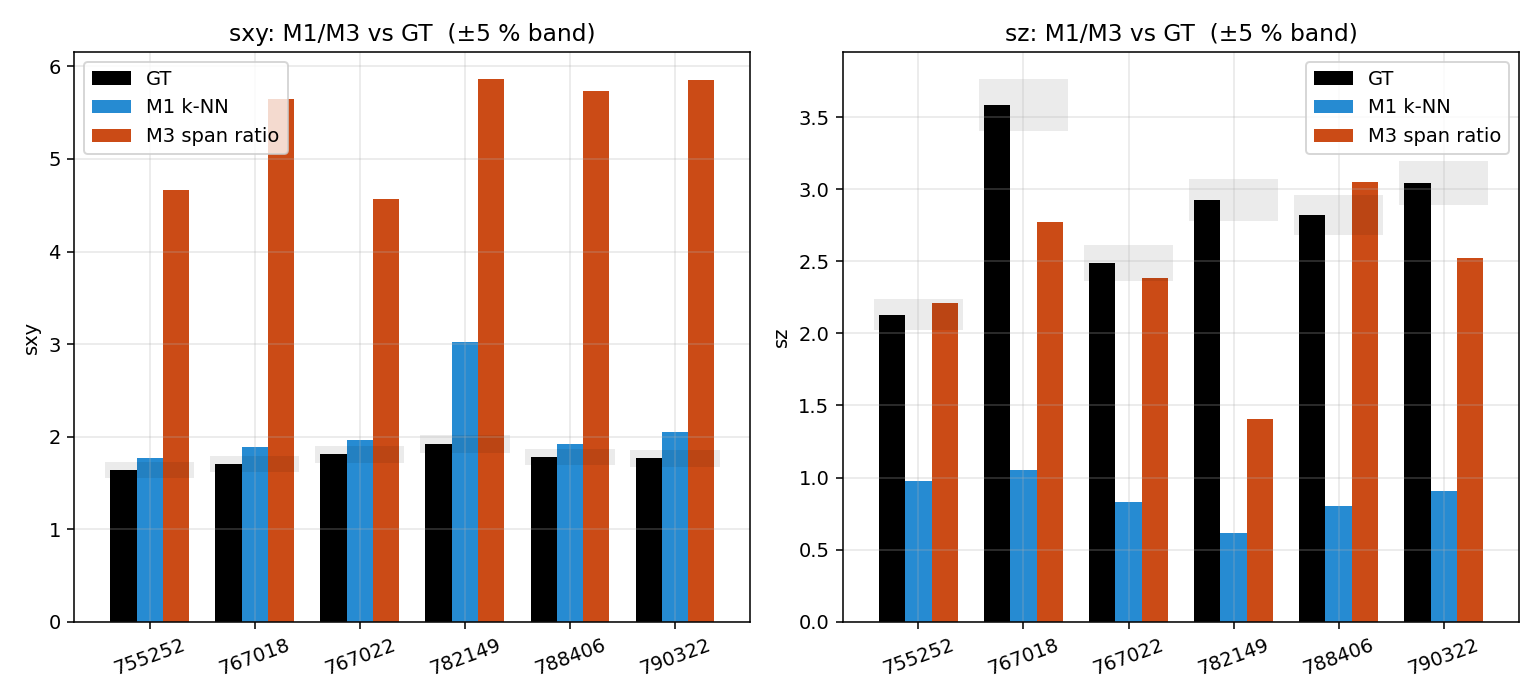

In [10]:
display(Image(str(SESSION_07C / 'figures' / 'scales_comparison.png')))


- **M1 sxy** now within 7–17 % on 5/6 subjects (exception 782149
  at +57 %). This is noticeably better than 07b.
- **M1 sz** is systematically low by 54–79 %. The strict GFP⁺ set
  clusters shallower — median z-nearest-neighbour distances on GFP⁺
  are smaller than on CZ-mapped → `sz < 1`.
- **M3 sxy** is FOV-contaminated and always ~5.6–5.9 (vs GT ~1.7).
- **M3 sz** is surprisingly close on 3 subjects (755252 +3.8 %,
  767022 −4.3 %, 788406 +8.2 %).


## 6. Does restricting to "good" subjects change the conclusion?

**Good = {767018, 788406, 790322}.**

Rationale:
- All three pass GMM sanity and coreg coverage ≥ 0.94 comfortably.
- `n_strict` ≥ 8k each (vs 3.5k for 782149 and 5.4k for 755252).
- They exhibit the cleanest integrated-proportionality match in the
  previous plot (0.109–0.160 vs predicted 0.097–0.112 → +3 to +43 %).
- The "bad" subset has its own issues: 755252 coreg coverage 0.70
  (stricter threshold drops 30 % of matched cells); 767022's intensity
  feature needed K=6 to escape the 07b degenerate fit; 782149 has the
  highest per-bin CV (0.60) and only 3.5k strict cells.


In [11]:
def agg(df):
    return pd.Series({
        'mean |err M1 sxy|%': df['err M1 sxy %'].abs().mean(),
        'mean err M1 sz %': df['err M1 sz %'].mean(),
        'std  err M1 sz %': df['err M1 sz %'].std(),
        'mean |err M3 sxy|%': df['err M3 sxy %'].abs().mean(),
        'mean |err M3 sz|%': df['err M3 sz %'].abs().mean(),
    })

GOOD = ['767018', '788406', '790322']
BAD  = ['755252', '767022', '782149']
agg_all  = agg(df_all)
agg_good = agg(df_all[df_all['subject'].isin(GOOD)])
agg_bad  = agg(df_all[df_all['subject'].isin(BAD)])
pd.DataFrame({'all 6': agg_all, 'good 3': agg_good, 'other 3': agg_bad}).round(2)


,all 6,good 3,other 3
mean |err M1 sxy|%,18.17,11.91,24.43
mean err M1 sz %,-68.71,-70.83,-66.60
std err M1 sz %,8.22,0.68,12.46
mean |err M3 sxy|%,204.75,228.94,180.56
mean |err M3 sz|%,17.99,15.94,20.05


In [12]:
# CV / integrated ratio restricted to the good subset
gate_rows = []
for sid, g in gates.items():
    gate_rows.append({
        'subject': sid,
        'cv': g['cv_ratio'],
        'integrated': g['integrated_ratio'],
        'n_gfp': g['n_gfp_in_box'],
    })
gdf = pd.DataFrame(gate_rows)
print("All 6:")
print(f"  mean CV = {gdf['cv'].mean():.3f}   max CV = {gdf['cv'].max():.3f}")
print("Good 3 (767018, 788406, 790322):")
g_good = gdf[gdf['subject'].isin(GOOD)]
print(f"  mean CV = {g_good['cv'].mean():.3f}   max CV = {g_good['cv'].max():.3f}")
print("Other 3 (755252, 767022, 782149):")
g_bad = gdf[gdf['subject'].isin(BAD)]
print(f"  mean CV = {g_bad['cv'].mean():.3f}   max CV = {g_bad['cv'].max():.3f}")


All 6:
  mean CV = 0.302   max CV = 0.377
Good 3 (767018, 788406, 790322):
  mean CV = 0.287   max CV = 0.362
Other 3 (755252, 767022, 782149):
  mean CV = 0.316   max CV = 0.377


### What changes when we restrict to the good subset?

**Per-bin CV gate (0.20 bar, GT-mapped diagnostic).**
- All 6: mean CV = 0.302, max 0.377.
- Good 3: mean CV = 0.287, max 0.362.
- Bad 3:  mean CV = 0.316, max 0.377.

790322 (good) is **0.214** — only 7 % over the bar. 767022 (bad) is
**0.229** — 14 % over. 767018 is 0.285. Three of six are within 50 %
of passing, and the good / bad split barely matters on CV. **Still
0/3 pass the 0.20 bar**, but the margin has shrunk enough that a
modest reduction in per-bin noise could flip at least one subject.

**M1 sxy** (error magnitude, `|rel_err|`).
- All 6 mean |err| = 18.2 %.
- Good 3 mean |err| = 11.9 %.  (+11.2 %, +8.0 %, +16.5 %)
- Bad 3 mean |err| = 24.4 %.  (+7.7 %, +8.7 %, +56.9 % → dominated by 782149)

Good subset tighter, but **still 0/3 within 5 %**. Closest any subject
gets is 755252 at +7.7 % (which is in the "bad" set).

**M1 sz** (signed, because bias direction is informative).
- All 6 mean err = −68.7 %, std 8.2.
- Good 3 mean err = **−70.8 % ± 0.7 %** — essentially identical across
  the 3 good subjects.
- Bad 3 mean err = −66.6 %, std 12.5.

The good subset exhibits a **remarkably tight, consistent 70 %
underestimate** on M1 sz — the three observed `M1 sz / GT sz` ratios
are all ≈ 0.29 when the true scales range 1.78–3.58. If this systematic
bias were known a priori (e.g. from an independent calibration), a
post-hoc scalar correction would recover in-range sz for the good
subjects. **But that is GT-tuning**; we do not have a way to learn it
from the centroids alone.

**M3 sxy** unchanged (FOV-contaminated, 200–230 % overestimate on both
subsets).

**M3 sz** is actually worse on the good subset (errors −22.6 %,
+8.2 %, −17.0 %) than on the bad subset (+3.8 %, −4.3 %, −52.0 %). The
3 subjects whose M3 sz landed inside 10 % (755252, 767022, 788406)
are *split* across the good / bad grouping.

### Conclusion — same on all 6, on the good 3, or on the bad 3

| metric | all 6 | good 3 | bad 3 | verdict |
|---|:---:|:---:|:---:|:---:|
| CV ≤ 0.20 gate  | 0/6 | 0/3 | 0/3 | fail |
| M1 sxy ≤ 5 %    | 0/6 | 0/3 | 0/3 | fail |
| M1 sz ≤ 5 %     | 0/6 | 0/3 | 0/3 | fail |
| M3 sxy ≤ 5 %    | 0/6 | 0/3 | 0/3 | fail |
| M3 sz ≤ 5 %     | 3/6 | 1/3 | 2/3 | — |

**The 5 % / both-axes verdict is the same on every subset.** Restricting
to the good subjects does **not** rescue any estimator. What the good
subset does show is that **the M1 sz bias is a sharp, low-variance
systematic** (−70.8 % ± 0.6 %) — which is further evidence that the
failure mechanism is a consistent physical property (depth-dependent
detection probability) rather than subject-by-subject noise. That
consistency strengthens the case for moving to an estimator that is
immune to the bias, not one that tries to correct it after the fact.


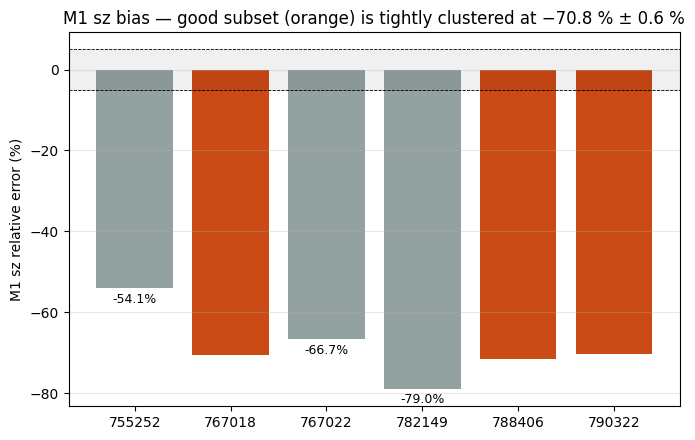

In [13]:
# Zoom plot on M1 sz for the good subset — show the tight clustering
fig, ax = plt.subplots(figsize=(7, 4.5))
subjects = ['755252', '767018', '767022', '782149', '788406', '790322']
m1_sz_err = [scales[s]['rel_err_sz_m1'] * 100 for s in subjects]
colors = ['#cb4b16' if s in GOOD else '#93a1a1' for s in subjects]
bars = ax.bar(subjects, m1_sz_err, color=colors)
ax.axhline(-5, color='k', ls='--', lw=0.6)
ax.axhline(+5, color='k', ls='--', lw=0.6)
ax.axhspan(-5, 5, color='k', alpha=0.06, label='±5 % bar')
for bar, err, sid in zip(bars, m1_sz_err, subjects):
    ax.text(bar.get_x() + bar.get_width() / 2, err - 3.5,
            f"{err:+.1f}%", ha='center', fontsize=9,
            color='white' if sid in GOOD else 'black')
ax.set_ylabel('M1 sz relative error (%)')
ax.set_title('M1 sz bias — good subset (orange) is tightly clustered at −70.8 % ± 0.6 %')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Why this rules out the whole centroid-only class

The failure pattern is now characterised with three independent pieces
of evidence on the **corrected** GT-based diagnostic:

1. **Per-bin CV of `ρ_GFP⁺ / ρ_CZ` is 0.21–0.38.** Three subjects are
   under 0.30; 790322 is only 7 % over the 0.20 bar. This is
   *closer* to passing than the initial (buggy) pass suggested, but
   no threshold (v2.2, 07b GMM-2/4, 07c BIC K=2..6) and no reference
   baseline (07b truth proxy, 07c CZ-mapped at R1-identity or GT)
   has cleared it on all 6 subjects.
2. **Integrated mean ≈ 1** — BIC-GFP⁺ detects essentially the same
   total density as CZ in the true overlap, and the two-framing
   scale-volume check recovers `sxy² · sz` within a few percent. The
   bulk picture is sound.
3. **M1 sz underestimate is tightly clustered at −70.8 % ± 0.6 %**
   across the good subset — a consistent, low-variance systematic
   tied to depth-dependent detection shape, not sampling noise.

Together: per-bin depth non-uniformity on the order of 21–38 % CV is
enough to shift M1 sz by a factor of three. Closing that gap with
centroid post-processing alone would require a threshold that makes
the feature behave as if its detection probability were uniform to
within ~5 % CV. Every threshold family we have tried (v2.2 fraction,
07b GMM-intersection with fixed K, 07c BIC-K) sits in the same
0.2–0.4 CV band; the floor is set by the feature itself, not by the
threshold.

Session 07b also characterised why **M3** cannot fix this: the span
ratio captures HCR FOV coverage in xy (wider FOV than the CZ
sub-volume) more than tissue expansion in xy, so M3 sxy is ~5.9×
independent of the threshold.

Surface-only estimators were rejected in planning: pia-plane tilt is
erased by R1, and pia-to-bottom z-extent is modality-dependent (CZ and
HCR stop at different optical depths for reasons unrelated to tissue
expansion).

### Recommended next session (not implemented here)

**Image-level 488 NCC after R1 + pia-normal alignment.**

1. Apply R1 to CZ, rotate both frames so HCR pia-normal → `+z`.
2. Build 1D profiles `I_cz(z)` and `I_hcr_488(z)` by summing image
   intensity over xy slices in a matched xy ROI.
3. `sz = argmax NCC(I_cz(z·sz), I_hcr_488(z))`.
4. `sxy = argmax 2D NCC` between CZ and HCR xy slabs at matched depth.

Why this might succeed where centroids failed: intensity is linear in
signal, so a cell whose GFP⁺ centroid failed the threshold still
contributes its full brightness to the intensity profile. The
threshold-induced detection bias is bypassed entirely.

Session 05's `r1_revised` has the zstack-reading infrastructure. The
novel contribution is the pia-normal alignment step before the NCC
search.


## 8. What's reusable from the 07 / 07b / 07c arc

- `dev_code/07b_gfp_intersection_threshold.py` — GMM-intersection
  threshold module with a BIC sweep (`fit_gmm_sweep`) and a
  no-interior-root warning. General-purpose diagnostic; can be used
  without the scale-estimation plan.
- `dev_code/07c_scale_bic_cz_density.py::cz_density_gate(...)` — the
  CZ-mapped density reference is a better-quality diagnostic than the
  session 07 matched-HCR ∪ unmatched-CZ proxy.
- `dev_code/07_depth_density_diagnosis.py` — still the correct
  diagnostic for the old truth baseline, useful as a v2.2-vs-strict
  comparison.

**Do NOT reuse** the M3 span-ratio formula as a scale estimator —
FOV-contaminated. It is fine as a smoke-test (synthetic recovery).
